In [1]:
from notebook_setup import add_project_path_to_notebook
add_project_path_to_notebook()

In [2]:
from microtorch.utils.paths import PROJECT_ROOT, SIMULATION_PATH

print("Found project root and path to simulated data at the following locations")
print(f"Project root: {PROJECT_ROOT}")
print(f"Simulation path: {SIMULATION_PATH}")

Found project root and path to simulated data at the following locations
Project root: /Users/scmps8/repos/github.com/microtorch/src/microtorch
Simulation path: /Users/scmps8/repos/github.com/microtorch/simulation_data


In [3]:
import os

#define the path to the simulation data
DATA_PATH = os.path.join(SIMULATION_PATH,"data")

#define the path to the fit output directory
OUTPUT_PATH = os.path.join(PROJECT_ROOT.parent.parent,"outputs")

#find the models where simulation data exists
simulation_data_models = [f for f in os.listdir(DATA_PATH) if not f.startswith(".")]

In [4]:
import glob
import nibabel as nib
from microtorch.utils.helpers import most_recent_output_file
import torch
from microtorch.utils.preprocessing import img2voxel

sim_data = {}
models = ["Ballt2"]
network_types = ["dev_mlp", "hidden_dropout_mlp", "vae", "cnn"]

for model in models:
    #get the simulated data, ground truth parameters and mask for each model and store in a dictionary
    sim_data[model + "_data"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_data.nii.gz"))[0]).get_fdata())
    sim_data[model + "_gt_params"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_params.nii.gz"))[0]).get_fdata())
    sim_data[model + "_mask"] = torch.from_numpy(nib.load(glob.glob(os.path.join(DATA_PATH, model, "*_mask.nii.gz"))[0]).get_fdata())

    #flatten the parameter maps and mask
    sim_data[model + "_gt_params_flat"], sim_data[model + "_mask_flat"] = img2voxel(sim_data[model + "_gt_params"], sim_data[model + "_mask"])

    for network_type in network_types:    
        #get the fitted parameters for each model and store in the dictionary
        try:
            sim_data[model + "_" + network_type + "_fitted_params"] = torch.from_numpy(nib.load(most_recent_output_file(OUTPUT_PATH, model, network_type)).get_fdata())
            print(f"Fitted parameters found and loaded for model {model} and network type {network_type}.")
            #flatten the fitted parameter maps
            sim_data[model + "_" + network_type + "_fitted_params_flat"], _ = img2voxel(sim_data[model + "_" + network_type + "_fitted_params"], sim_data[model + "_mask"])
        except:
            print(f"No fitted parameters found for model {model} and network type {network_type}. Skipping.")       
            simulation_data_models = [m for m in simulation_data_models if m != model]  #remove the model from the list of models 
    
    

Fitted parameters found and loaded for model Ballt2 and network type dev_mlp.
Fitted parameters found and loaded for model Ballt2 and network type hidden_dropout_mlp.
Fitted parameters found and loaded for model Ballt2 and network type vae.
Fitted parameters found and loaded for model Ballt2 and network type cnn.


No YAML configuration found for Ballt2 model.
Falling back to parsing model name for compartments: ['Ballt2'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ballt2
########### Compartments: ['Ballt2']
########### Parameter names: [['D', 'T2']]
########### Parameter ranges: [[[0.001, 3.0], [0.01, 0.5]]]
-----------


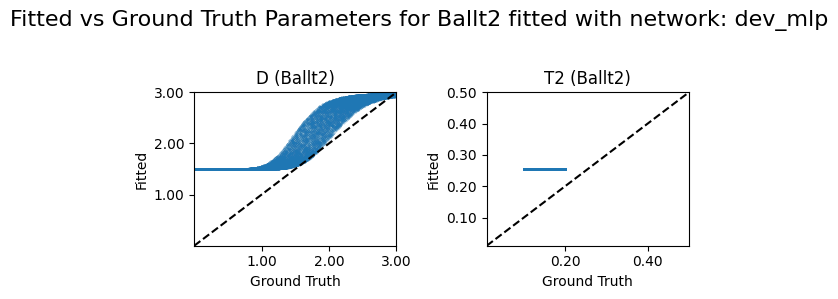

No YAML configuration found for Ballt2 model.
Falling back to parsing model name for compartments: ['Ballt2'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ballt2
########### Compartments: ['Ballt2']
########### Parameter names: [['D', 'T2']]
########### Parameter ranges: [[[0.001, 3.0], [0.01, 0.5]]]
-----------


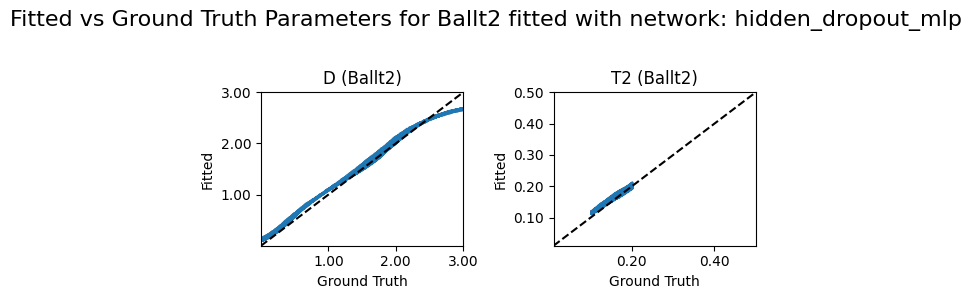

No YAML configuration found for Ballt2 model.
Falling back to parsing model name for compartments: ['Ballt2'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ballt2
########### Compartments: ['Ballt2']
########### Parameter names: [['D', 'T2']]
########### Parameter ranges: [[[0.001, 3.0], [0.01, 0.5]]]
-----------


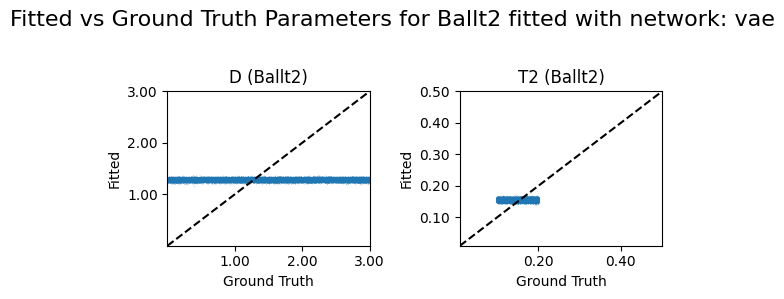

No YAML configuration found for Ballt2 model.
Falling back to parsing model name for compartments: ['Ballt2'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ballt2
########### Compartments: ['Ballt2']
########### Parameter names: [['D', 'T2']]
########### Parameter ranges: [[[0.001, 3.0], [0.01, 0.5]]]
-----------


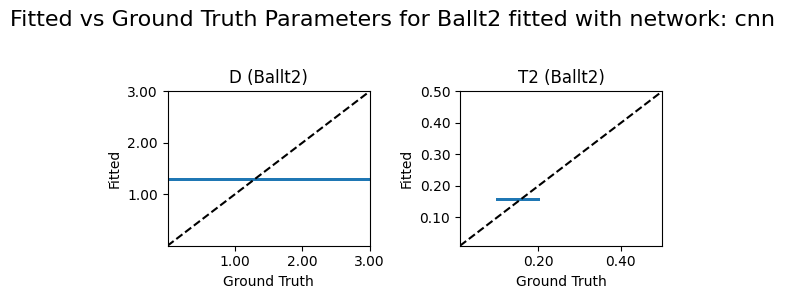

In [5]:
from microtorch.utils.plot_results import plot_fitted_vs_gt, plot_fitted_vs_gt_for_model

for model in models:
    for network_type in network_types: 

        title = f"Fitted vs Ground Truth Parameters for {model} fitted with network: {network_type}"

        fig, _ = plot_fitted_vs_gt_for_model(sim_data[model + "_gt_params_flat"], sim_data[model + "_" + network_type + "_fitted_params_flat"], model, title=title)
        

        